In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from ucimlrepo import fetch_ucirepo 
import matplotlib.pyplot as plt
import random
from zonolayer import compute_zonolayer_bounds, compute_ipm_bounds

def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [2]:
class RegressionNetwork(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=8, zono_dim=3):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, zono_dim)
        )
        self.regressor = nn.Linear(zono_dim, 1)

    def forward(self, x, return_features=False):
        features = self.feature_extractor(x)
        out = self.regressor(features)
        if return_features:
            return out, features
        return out


def train_centre(x_t, y_lb_t, y_ub_t, epochs=8000, lr=0.01, print_every=50):
    y_mid = (y_lb_t + y_ub_t) / 2

    centre_net = RegressionNetwork(input_dim=x_t.shape[1])
    optimizer = torch.optim.Adam(centre_net.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.MSELoss()

    for epoch in range(epochs):
        pred = centre_net(x_t)
        loss = criterion(pred, y_mid)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (epoch + 1) % print_every == 0:
            print(f"Epoch {epoch+1}: MSE = {loss.item():.6f}")

    return centre_net

def artificial_dataset(n):
    x = np.random.rand(n).reshape(-1, 1)
    y = np.sin(2 * np.pi * x**2) * np.exp(-x) + \
        1 + np.random.normal(0, 0.15, (n, 1))
    rad = np.abs(np.random.normal(0.1, 0.05, (n, 1)))
    return x, y, y - rad, y + rad

x, y, y_lower, y_upper = artificial_dataset(400)

In [3]:
def extract_latent_features(model, x):
    model.eval()
    with torch.no_grad():
        preds, features = model(x, return_features=True)
    return preds.cpu().numpy(), features.cpu().numpy()

x_t = torch.tensor(x, dtype=torch.float32)
y_lb_t = torch.tensor(y_lower, dtype=torch.float32)
y_ub_t = torch.tensor(y_upper, dtype=torch.float32)
x_grid = np.linspace(0, 1, 400).reshape(-1, 1)

centre_net = train_centre(x_t, y_lb_t, y_ub_t)
pred_train, latent_train = extract_latent_features(centre_net, x_t)
pred_test, latent_test = extract_latent_features(centre_net, torch.tensor(x_grid, dtype=torch.float32))

zonolayer = compute_zonolayer_bounds(latent_train, y_lower, y_upper, latent_test)
ipm_upper, ipm_lower = compute_ipm_bounds(latent_train, latent_test, y_lower, y_upper)

Epoch 50: MSE = 0.121579
Epoch 100: MSE = 0.105026
Epoch 150: MSE = 0.102834
Epoch 200: MSE = 0.099071
Epoch 250: MSE = 0.091221
Epoch 300: MSE = 0.074408
Epoch 350: MSE = 0.050971
Epoch 400: MSE = 0.037785
Epoch 450: MSE = 0.035221
Epoch 500: MSE = 0.034015
Epoch 550: MSE = 0.033123
Epoch 600: MSE = 0.032389
Epoch 650: MSE = 0.031749
Epoch 700: MSE = 0.031170
Epoch 750: MSE = 0.030636
Epoch 800: MSE = 0.030136
Epoch 850: MSE = 0.029664
Epoch 900: MSE = 0.029215
Epoch 950: MSE = 0.028783
Epoch 1000: MSE = 0.028369
Epoch 1050: MSE = 0.027974
Epoch 1100: MSE = 0.027603
Epoch 1150: MSE = 0.027261
Epoch 1200: MSE = 0.026950
Epoch 1250: MSE = 0.026672
Epoch 1300: MSE = 0.026425
Epoch 1350: MSE = 0.026207
Epoch 1400: MSE = 0.026015
Epoch 1450: MSE = 0.025844
Epoch 1500: MSE = 0.025692
Epoch 1550: MSE = 0.025554
Epoch 1600: MSE = 0.025428
Epoch 1650: MSE = 0.025311
Epoch 1700: MSE = 0.025200
Epoch 1750: MSE = 0.025092
Epoch 1800: MSE = 0.024984
Epoch 1850: MSE = 0.024873
Epoch 1900: MSE = 0.0

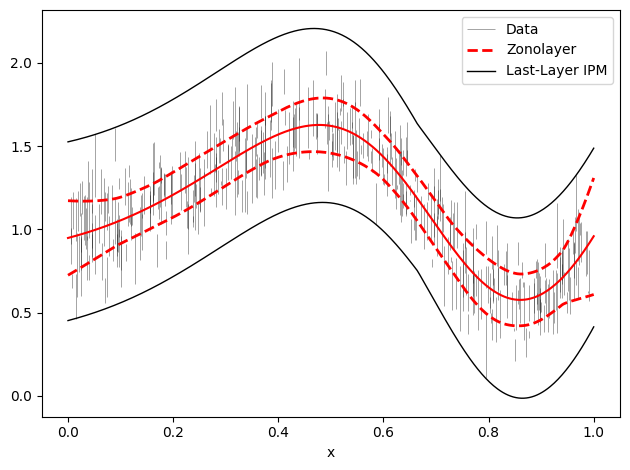

In [4]:
yl_zl = zonolayer["y_lower"]
yu_zl = zonolayer["y_upper"]
midpoint_model = zonolayer["midpoint"]

plt.figure()

x_plot = x_grid.squeeze()
sorted_idx = np.argsort(x_plot)

# x_data = x[sorted_idx].squeeze()
y_lower_data = y_lower[sorted_idx].squeeze()
y_upper_data = y_upper[sorted_idx].squeeze()

plt.vlines(x, y_lower_data, y_upper_data,
           color='black', alpha=0.5, linewidth=0.5, label='Data')

# Zonotope
plt.plot(x_plot, yl_zl, 'r--', lw=2, label='Zonolayer')
plt.plot(x_plot, yu_zl, 'r--', lw=2)

# IPM
plt.plot(x_plot, ipm_lower, 'black', lw=1, label='Last-Layer IPM')
plt.plot(x_plot, ipm_upper, 'black', lw=1)

plt.plot(x_plot, midpoint_model, 'r-', lw=1.5)

plt.xlabel("x")
plt.legend()
plt.tight_layout()

plt.savefig("LastLayerIPM.pdf", bbox_inches="tight")
plt.show()